In [87]:
import numpy as np
from scipy.stats import norm
import math
from scipy.optimize import minimize_scalar
from pathlib import Path
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = 'svg'

In [88]:
class JNDModel:
    
    def __init__(self, L_MIN = 0.1, L_MAX = 300, t = 1, phi_d_screen = 1e-3, p = 0.75):
        self.L_MIN = L_MIN
        self.L_MAX = L_MAX
        self.t = t # время экспозиции (наблюдения) объекта в секундах
        self.phi_d_screen = phi_d_screen # угловой размер пикселя на экране (в радианах)
        self.phi_d = phi_d_screen # угловой размер объекта (в радианах)
        self.p = p # требуемая вероятность обнаружения объекта
        self.L0 = 1e-6
    
    @classmethod
    def from_screen_params(cls, screen_diag_inch = 16, screen_width_px = 1920, screen_height_px = 1080, distance_m = 0.5,
                           l_gray = 60, **kwargs):
        '''
        Фабричный метод для инициализации JNDModel с рассчетом phi_d на основе параметров экрана
        '''
        diag_px = math.sqrt(screen_width_px ** 2 + screen_height_px ** 2)
        ppi = diag_px / screen_diag_inch
        
        pixel_size_m = 0.0254 / ppi # 1 дюйм = 0.0254 метра

        phi_d_screen = pixel_size_m / distance_m # считаем угловой размер пикселя на экране

        instance = cls(phi_d_screen=phi_d_screen, **kwargs)

        instance.screen_width_px = screen_width_px
        instance.screen_height_px = screen_height_px
        instance.ppi = ppi
        instance.l_gray = l_gray

        return instance

    def _K(self, lambd, b1 = 0.98, b2 = 0.1, lambd1 = 2e-2):
        lambd = np.asarray(lambd, dtype = np.float64)
        return np.where(lambd <= 1, b1 * (1 + lambd1 / lambd), lambd ** b2)
    
    def _A(self, La, a1 = 4.8e6, a2 = 7.1e3, a3 = 4.5e-4): # единицы измерения параметров a1, a2, a3: м ** 2 / кд
        '''
        Функция, характеризующая ослабление сигнала в зрительной системе в результате процесса яркостной адаптации 
        к однородному фону с яркостью La

        '''
        return 1 + (a1 * La) ** 0.5 + a2 * La * (1 + (a3 * La) ** 0.5) # формула 9.6
    
    def _Lambda(self, lambd):
        return lambd * self._K(lambd)
    
    def _eta(self, La, L3 = 1e6, L4 = 1, a4 = 600): # единицы измерения параметров L3: кд / м ** 2, L4: кд / м ** 2, a4: м ** 4 / кд ** 2
        '''
        Функция адаптации временных интервалов

        '''
        return 1 + L3 / (1 + a4 * La * (L4 + La)) # Формула 9.12
    
    def _C(self, La, t): # единицы измерения: c
        tao_min = 0.05 # минимальное значение времени инерции зрения
        T = t / (tao_min * self._eta(La)) # формула 9.7
        return 1 + 1 / T # Формула 9.10. При имплементации выбрал 1 вариант из статьи. Есть 2 вариант - формула 9.11: C = 1 / (1 - exp(-T))
    
    def _func_phi_1(self, La, c2 = 0.25, L1 = 10, L2 = 2.6e-5): # единицы измерения параметров L1, L2: кд / м ** 2
        return (1 + L1 / (L2 + La)) ** c2 # формула 9.4
    
    def _S(self, La, theta_1 = 6.1, a_d = 2, inf_phi_1 = 1):
        phi_0_min = 0.5 * (1 / 60) * (np.pi / 180) # phi_0_min = 0,5' - 1'
        phi_1 = self._func_phi_1(La)
        phi_0 = phi_1 * phi_0_min / inf_phi_1
        
        return (theta_1 * phi_0 / self.phi_d + 1.0) ** a_d # формула 9.2
    
    def _l(self, La):
        return self.L0 * self._A(La) # формула 9.5
    
    def _P(self, p, p_ref = 0.75):
        '''
        Пороговая функция вероятности обнаружения, в статье не описано что это за функция. 
        Решил взять отношение необходимых сдвигов распределения при которых площадь по графиком шума глаза + сигнала равна соотвественно p_ref и p

        p_ref - веротность, с котороый мы РЕАЛЬНО в экспериментах статьи видим разницу в измении на 1 уровень яркости
        p - веротность, с котороый мы хотим чтобы была видна разница в измении на 1 уровень яркости

        В статье p_ref = 0.75 не фигурирует, так что в экспериментах используется p = p_ref = 0.75, чтобы множитель 
        от функции P не вносил ничего в итоговую формулу (P = 1)

        '''
        return abs(norm.ppf(p) / norm.ppf(p_ref))

    def _D(self, L, La): # единицы измерения параметра L0: кд / м ** 2
        '''
        L0 - абсолютный световой порог - минимальное значение яркости, которое человек способен заметить

        A(La) - адаптационное ослабление сигнала, зависит от яркости адаптации, регулировка чувствительности 
        к яркости в зависимости от фона

        C(La, t) - временная обработка, зависит от времени экспозиции t и яркости адаптации

        Lambda(lambd) - амплитудная обработка, зависит от lambd - нормализованной разницой между яркостью объекта 
        и яркостью адаптации, описывает нелинейность вопсприятия

        S(La, phi_d) - пространственная обработка, учитывает угловой размер объекта (phi_d) и минимальный угол разрешения глаза (phi_0)

        P(p) - пороговая функция вероятности обнаружения, позволяет учесть вероятность с которой мы хотим видеть объект

        '''
        lambd = L / (10 ** 2 * self._l(La)) # формула 9.13
        return self.L0 * self._A(La) * self._C(La, self.t) * self._Lambda(lambd) * self._S(La) * self._P(self.p) # формула 9.16

    def find_La(self, L_matrix):
        EPS = 1e-12
        logL = np.log(np.maximum(L_matrix, EPS))
    
        # Границы можно расширить, если адаптация может лежать вне диапазона яркостей картинки.
        log_La_min = float(logL.min())
        log_La_max = float(logL.max())
    
        def S_score(L_matrix, start_La):
            numerator = self._D(L_matrix, start_La)
            denominator = self._D(L_matrix, L_matrix)
            return float(np.mean(np.log(numerator / denominator)))
        
        def objective_log_La(log_La):
            return S_score(L_matrix, math.exp(float(log_La)))
        
        result = minimize_scalar(
            objective_log_La,
            bounds=(log_La_min, log_La_max),
            method='bounded',
            options={'xatol': 1e-6},
        )
        
        log_La_star = float(result.x)
        self.La = math.exp(log_La_star)
        
        return self.La

    def find_La_with_background(self, L_patch, optimizer = 'minimize_scalar', target_width_cm = None):
        '''
        L_patch подается в оригинальном разрешении
        
        '''
        if (isinstance(L_patch, np.ndarray) and L_patch.size > 0 and L_patch.ndim == 2):
            h_patch_px, w_patch_px = L_patch.shape
            aspect_ratio = h_patch_px / w_patch_px

            if target_width_cm is None:
                target_w_px = w_patch_px
                target_h_px = h_patch_px
            else:
                target_w_px = int(np.round((target_width_cm / 2.54) * self.ppi))
                target_h_px = int(np.round(target_w_px * aspect_ratio))

            n_patch_screen = target_w_px * target_h_px

            scale = target_w_px / w_patch_px
            self.phi_d = scale * self.phi_d_screen
        else:
            n_patch_screen = 0
            self.phi_d = self.phi_d_screen

        n_total = self.screen_width_px * self.screen_height_px
        
        n_bg = n_total - n_patch_screen

        logL = np.log(np.maximum(L_patch, 1e-12))
        # log_La_min = float(min(logL.min(), np.log(self.l_gray)))
        # log_La_max = float(max(logL.max(), np.log(self.l_gray)))
        log_La_min = -3.0 # La = 0.05
        log_La_max = 6.0 # La = 403.43

        def objective_log_La(log_La):
            curr_La = math.exp(float(log_La))
        
            # Считаем для пикселей патча
            num_patch = self._D(L_patch, curr_La)
            den_patch = self._D(L_patch, L_patch)
            sum_patch = np.sum(np.log(num_patch / den_patch))
            
            # 2. Для фона считаем одно число и умножаем на количество пикселей фона
            num_bg = self._D(self.l_gray, curr_La)
            den_bg = self._D(self.l_gray, self.l_gray)
            sum_bg = n_bg * np.log(num_bg / den_bg)
            
            return float((sum_patch + sum_bg) / n_total) # считаем фон и саму картинку равнозначными

        if optimizer == 'minimize_scalar':

            history_x = []
            history_loss = []

            def tracked_objective(log_la):
                loss = objective_log_La(log_la)
                history_x.append(float(log_la))
                history_loss.append(float(loss))
                return loss

            result = minimize_scalar(
                tracked_objective,
                bounds=(log_La_min, log_La_max),
                method='bounded',
                options={'xatol': 1e-6},
            )

            self.La = math.exp(float(result.x))

            if True:
                grid_x = np.linspace(log_La_min, log_La_max, 300)
                grid_loss = [objective_log_La(x) for x in grid_x]

                plt.figure(figsize=(10, 5))
                plt.plot(
                    grid_x,
                    grid_loss,
                    label='Loss Landscape',
                    color='gray',
                    linewidth=2,
                )
                plt.plot(
                    history_x,
                    history_loss,
                    color='steelblue',
                    linestyle='--',
                    alpha=0.6,
                    label='Search Path',
                )

                scatter = plt.scatter(
                    history_x,
                    history_loss,
                    c=range(len(history_x)),
                    cmap='viridis',
                    s=45,
                    zorder=3,
                    label='Evaluated Points',
                )
                plt.scatter(
                    result.x,
                    result.fun,
                    color='red',
                    marker='*',
                    s=160,
                    zorder=4,
                    label=f'Optimal La = {self.La:.2f}',
                )

                plt.colorbar(scatter, label='Step Index')
                plt.xlabel('log(La)')
                plt.ylabel('Loss')
                plt.title('Optimization Landscape and Trajectory')
                plt.grid(True, linestyle=':', alpha=0.6)
                plt.legend()
                plt.show()

        elif optimizer == 'log_grid_search':

            log_space = np.linspace(-3, 6, num=1000)

            best_la = 0
            min_loss = 1e10

            for log_la in log_space:
                loss = objective_log_La(log_la)
                if min_loss > loss:
                    min_loss = loss
                    best_la = np.exp(log_la)

            self.La = best_la
        
        return self.La

    def build_level_boundaries(self):
        L_right_bounds = []
        L_curr = self.La
        while L_curr < self.L_MAX:
            L_curr += self._D(L_curr, self.La)
            L_right_bounds.append(min(L_curr, self.L_MAX))

        L_left_bounds = []
        L_curr = self.La
        while L_curr > self.L0:
            L_curr -= self._D(L_curr, self.La)
            L_left_bounds.append(max(L_curr, self.L0))

        self.len_left = len(L_left_bounds)

        L_left_bounds.reverse()

        self.bounds = np.array(L_left_bounds + [self.La] + L_right_bounds)

        return self.bounds
    
    def L_to_k(self, L): # всегда берем нижнюю границу интервала, в который попали
        return np.searchsorted(self.bounds, L, side = 'right') - 1 - self.len_left
    
    def k_to_L(self, k): # всегда берем нижнюю границу интервала, в который попали
        return self.bounds[k + self.len_left]

In [89]:
class ImageConverter:
    def __init__(self):
        self.M = np.array([
            [0.4124564,  0.3575761,  0.1804375],
            [0.2126729,  0.7151522,  0.0721750],
            [0.0193339,  0.1191920,  0.9503041]
        ])
        self.M_inv = np.array([
            [ 3.1338561, -1.6168667, -0.4906146],
            [-0.9787684,  1.9161415,  0.0334540],
            [ 0.0719453, -0.2289914,  1.4052427]
        ])

    def read_img(self, image):
        V = cv2.imread(image)
        V = cv2.cvtColor(V, cv2.COLOR_BGR2RGB)
        return V.astype(np.float64)

    def normalize_image(self, image):
        if image.max() > 1:
            image = image / 255.0
        return image

    def sRGB_Companding(self, linear_image):
        linear = np.clip(np.asarray(linear_image, dtype=np.float64), 0.0, 1.0)
        
        encoded = np.where(
            linear <= 0.0031308,
            linear * 12.92,
            1.055 * (linear ** (1.0 / 2.4)) - 0.055
        )
        return encoded

    def Inverse_sRGB_Companding(self, image):
        img = np.asarray(image, dtype=np.float64)
        
        linear = np.where(
            img <= 0.04045,
            img / 12.92,
            ((img + 0.055) / 1.055) ** 2.4
        )
        return linear

    def Linear_RGB_to_XYZ(self, image):
        XYZ_image = image.reshape(-1, 3)
        return (XYZ_image @ self.M.T).reshape(image.shape)

    def XYZ_to_xyY(self, XYZ_image, L_MAX=300.0, coord_white=(0.3127, 0.3290)):
        sum_xyz = XYZ_image.sum(axis=-1, keepdims=True)
        eps = 1e-10
        xy = XYZ_image[..., :2] / (sum_xyz + eps)
        is_black = (sum_xyz.squeeze(-1) < eps)
        if np.any(is_black):
            xy[is_black] = coord_white
        Y = XYZ_image[..., 1]
        L_norm = np.clip(Y, 0.0, 1.0)
        return np.stack([xy[..., 0], xy[..., 1], L_norm], axis=-1)

    def XYZ_to_xzL(self, XYZ_image, L_MAX=300.0, coord_white=(0.3127, 0.3583)):
        sum_xyz = XYZ_image.sum(axis=-1)
        eps = 1e-10
        x = XYZ_image[..., 0] / (sum_xyz + eps)
        z = XYZ_image[..., 2] / (sum_xyz + eps)
        is_black = (sum_xyz < eps)
        if np.any(is_black):
            x[is_black] = coord_white[0]
            z[is_black] = coord_white[1]
        Y = XYZ_image[..., 1]
        L_norm = np.clip(Y, 0.0, 1.0)
        return np.stack([x, z, L_norm], axis=-1)

    def RGB_to_xyL(self, img, L_MAX=300.0,):
        
        V = self.read_img(img)
    
        # [0, 1]
        norm_img = self.normalize_image(V)
    
        # sRGB -> linRGB
        linRGBimg = self.Inverse_sRGB_Companding(norm_img)
    
        #linRGB -> XYZ
        XYZ_image = self.Linear_RGB_to_XYZ(linRGBimg)
    
        xyL_image = self.XYZ_to_xyY(XYZ_image, L_MAX)

        return xyL_image

    def L_to_RGB(self, L, L_MIN = 0.1, L_MAX = 300):
        '''
        L - число или матрица ненормированных яркостей
        '''

        Y_lin = (L - L_MIN) / (L_MAX - L_MIN)

        Y_lin = np.clip(Y_lin, 0.0, 1.0)

        V = self.sRGB_Companding(Y_lin)

        image = np.rint(V * 255).astype(np.uint8)

        return image

Считаем яркость адаптации чисто на однотонном изображении 1920 на 1080 с яркостью 60 нит. Сравниваем 2 метода оптимизации для исключения ошибки оптимизатора:

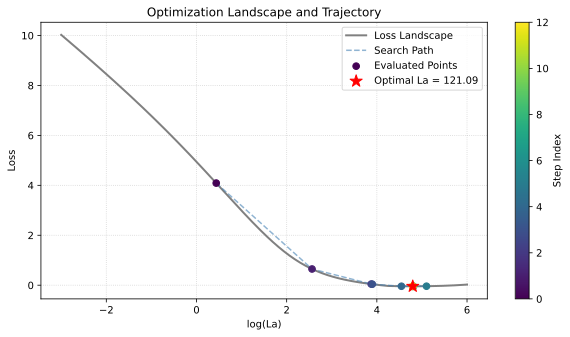

La (minimize scalar): 121.09040239628324
La (log grid search): 120.63781505242518


In [90]:
jnd_model = JNDModel.from_screen_params()

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='log_grid_search')
La_log_grid_search = jnd_model.La

jnd_model.find_La_with_background(L_patch=np.array([]), optimizer='minimize_scalar')
La_minimize_scalar = jnd_model.La

print(f'La (minimize scalar): {La_minimize_scalar}\nLa (log grid search): {La_log_grid_search}')

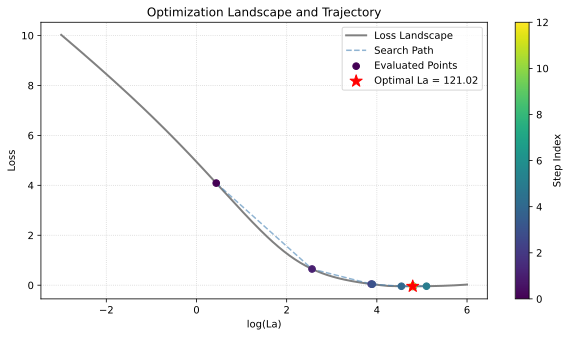

Target size: None
La (minimize scalar): 121.01505701758714
La (log grid search): 120.63781505242518
Phi d: 0.00036896697738272584



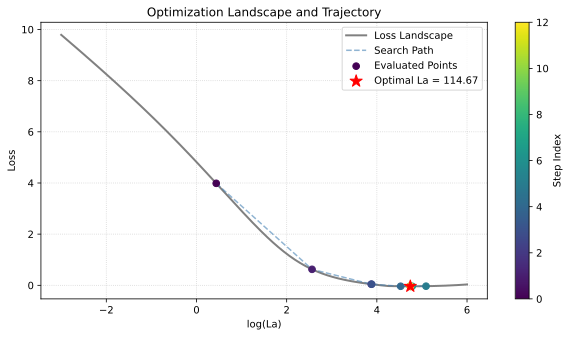

Target size: 1
La (minimize scalar): 114.66732441255175
La (log grid search): 114.28996123617947
Phi d: 0.0006226317743333498



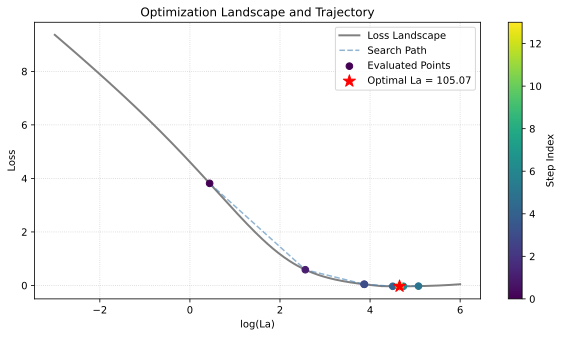

Target size: 2
La (minimize scalar): 105.0673763705446
La (log grid search): 105.3889358521704
Phi d: 0.0012452635486666997



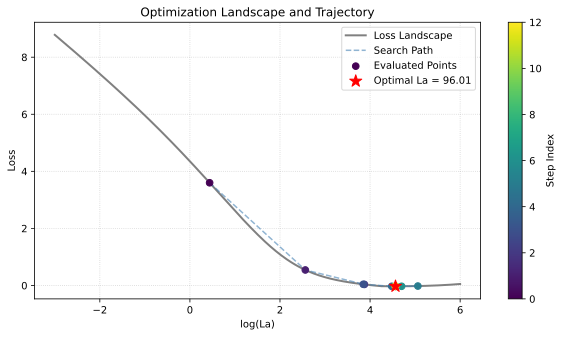

Target size: 4
La (minimize scalar): 96.01210231685872
La (log grid search): 96.30955813023232
Phi d: 0.0025020573153766096



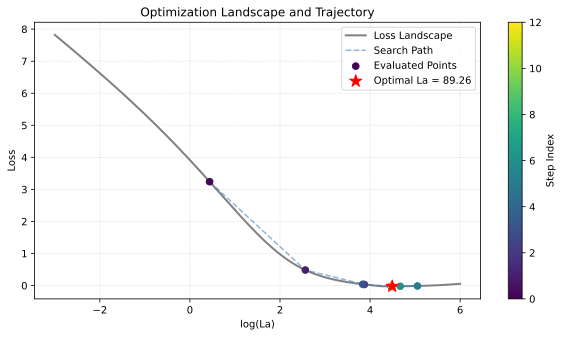

Target size: 8
La (minimize scalar): 89.26095154315693
La (log grid search): 89.61256060643328
Phi d: 0.005004114630753219



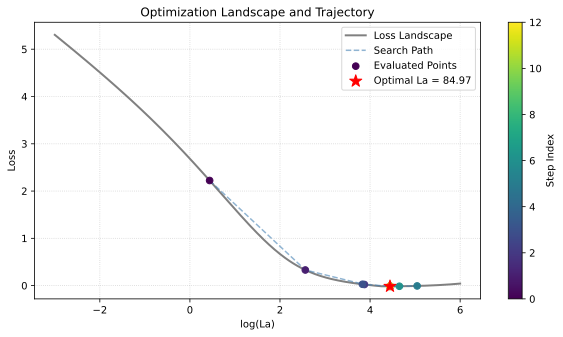

Target size: 16
La (minimize scalar): 84.97353567871829
La (log grid search): 84.89722790099687
Phi d: 0.009996699043463227



In [91]:
image_path = '../examples/cifar10_1.png'

jnd_model = JNDModel.from_screen_params()
converter = ImageConverter()

L_MIN = 0.1
L_MAX = 300

xyL_image = converter.RGB_to_xyL(image_path)
L_norm = xyL_image[..., 2]
L_patch = L_MIN + (L_MAX - L_MIN) * L_norm

for target_width_cm in [None, 1, 2, 4, 8, 16]:

    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='log_grid_search', target_width_cm=target_width_cm)
    La_log_grid_search = jnd_model.La

    jnd_model.find_La_with_background(L_patch=L_patch, optimizer='minimize_scalar', target_width_cm=target_width_cm)
    La_minimize_scalar = jnd_model.La

    print(f'Target size: {target_width_cm}\nLa (minimize scalar): {La_minimize_scalar}\nLa (log grid search): {La_log_grid_search}\nPhi d: {jnd_model.phi_d}')
    print()